In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from utils.dfCleaning import Cleaning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

----------
# Data Preprocessing
----------

In [28]:
df = pd.read_csv('../data/movies.csv')
df = Cleaning(df)
df

,Movie,Director,Running time,Actor 1,Actor 2,Actor 3,Genre,Budget,Box Office,Actors Box Office %,Director Box Office %,Earnings,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Release year,IMDb score
0,13 Hours,Michael Bay,144,Toby Stephens,James Badge Dale,David Costabile,Action,50000000,69400000,50.00,69.23,19400000,0,0.0,2016,7.4
1,16 Blocks,Richard Donner,102,Bruce Willis,David Zayas,Sasha Roiz,Action,52000000,65000000,33.33,50.00,13000000,0,0.0,2006,6.6
2,17 Again,Burr Steers,102,Matthew Perry,Hunter Parrish,Thomas Lennon,Comedy,20000000,139000000,44.44,25.00,119000000,0,0.0,2009,6.4
3,1982,Tommy Oliver,90,Bokeem Woodbine,Ruby Dee,Quinton Aaron,Drama,1000000,2000000,50.00,100.00,1000000,0,0.0,2013,7.1
4,2 Fast 2 Furious,John Singleton,107,Paul Walker,Cole Hauser,Mo Gallini,Action,76000000,236000000,75.00,42.85,160000000,0,0.0,2003,5.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897,Z Storm,David Lam,92,Michael Wong,Louis Koo,Stephen Au,Action,7000000,17000000,100.00,100.00,10000000,0,0.0,2014,5.3
3898,Zack and Miri Make a Porno,Kevin Smith,101,Gerry Bednob,Jeff Anderson,Jennifer Schwalbach Smith,Comedy,24000000,42000000,66.67,41.66,18000000,0,0.0,2008,6.6
3899,Zero Effect,Jake Kasdan,116,Kim Dickens,Ryan O'Neal,Angela Featherstone,Comedy,5000000,2000000,33.33,50.00,-3000000,0,0.0,1998,7.0
3900,Zombieland,Ruben Fleischer,88,Emma Stone,Bill Murray,Derek Graf,Adventure,23600000,102000000,66.67,33.33,78400000,0,0.0,2009,7.7


### Creating the Target Variable (Hit/Flop)

In [29]:
df["Hit/Flop"] = (df["Box Office"] > df["Budget"] * 2).astype(int)
df["Hit/Flop"].value_counts()

Hit/Flop
1    2006
0    1896
Name: count, dtype: int64

In [30]:
df.columns.tolist()

['Movie',
 'Director',
 'Running time',
 'Actor 1',
 'Actor 2',
 'Actor 3',
 'Genre',
 'Budget',
 'Box Office',
 'Actors Box Office %',
 'Director Box Office %',
 'Earnings',
 'Oscar and Golden Globes nominations',
 'Oscar and Golden Globes awards',
 'Release year',
 'IMDb score',
 'Hit/Flop']

### Creating Features For The Model

In [31]:
features = [
    'Running time',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3',
    'Genre',
    'Budget',
    'Actors Box Office %',
    'Director Box Office %',
    'Oscar and Golden Globes nominations',
    'Oscar and Golden Globes awards',
    'Release year'
]

In [32]:
X = df[features]
y = df['Hit/Flop']

In [33]:
num_features = [
    'Running time',
    'Budget',
    'Actors Box Office %',
    'Director Box Office %',
    'Oscar and Golden Globes awards',
    'Oscar and Golden Globes nominations',
    'Release year'
]

cat_features = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=10), cat_features)
    ]
)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3121, 12), (781, 12), (3121,), (781,))

In [37]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [38]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3121, 99), (781, 99), (3121,), (781,))

----------
# Building the Artificial Neural Network Model
_________

In [39]:
ann = Sequential()

### Adding Layers to the ANN

In [40]:
ann.add(Input(shape=(X_train.shape[1],)))
ann.add(Dense(16, activation='relu'))
ann.add(Dropout(0.1))

In [41]:
ann.add(Dense(16, activation='relu'))
ann.add(Dropout(0.1))

In [42]:
ann.add(Dense(16, activation='relu'))
ann.add(Dropout(0.1))

### Adding the Output Layer

In [43]:
ann.add(Dense(1, activation='sigmoid'))

### Compiling the ANN

In [44]:
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### Model Training

In [45]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    mode='max'
)
result = ann.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop])

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6410 - loss: 0.6622 - val_accuracy: 0.7904 - val_loss: 0.5778
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - accuracy: 0.7825 - loss: 0.5093 - val_accuracy: 0.8160 - val_loss: 0.4100
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - accuracy: 0.8061 - loss: 0.4337 - val_accuracy: 0.8208 - val_loss: 0.3955
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.7973 - loss: 0.4261 - val_accuracy: 0.8176 - val_loss: 0.3958
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - accuracy: 0.8081 - loss: 0.4080 - val_accuracy: 0.8096 - val_loss: 0.3948
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - accuracy: 0.8137 - loss: 0.4014 - val_accuracy: 0.8144 - val_loss: 0.3933
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - accuracy: 0.8165 - loss: 0.3897 - val_accuracy: 0.8192 - val_loss: 0.3961
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.8149 - loss: 0.3929 - val_accura

----------
# Model Evaluation
----------

### Evaluating the trained model on training data


In [46]:
y_train_pred = ann.predict(X_train)
y_train_pred = (y_train_pred > 0.5).astype(int)
cm = confusion_matrix(y_train, y_train_pred)
accuracy = accuracy_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)
print("Training Confusion Matrix:\n", cm)
print("Training Accuracy:", round(accuracy, 2))
print("Training F1 Score:", round(f1, 2))

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step
Training Confusion Matrix:
 [[1005  520]
 [ 163 1433]]
Training Accuracy: 0.78
Training F1 Score: 0.81


### Evaluating the trained model on testing data


In [47]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step


In [48]:
y_pred

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
    

In [49]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Testing Confusion Matrix:\n", cm)
print("Testing Accuracy:", round(accuracy, 2))
print("Testing F1 Score:", round(f1, 2))

Testing Confusion Matrix:
 [[251 120]
 [ 48 362]]
Testing Accuracy: 0.78
Testing F1 Score: 0.81


----------
# Visualizing Model Performance
----------

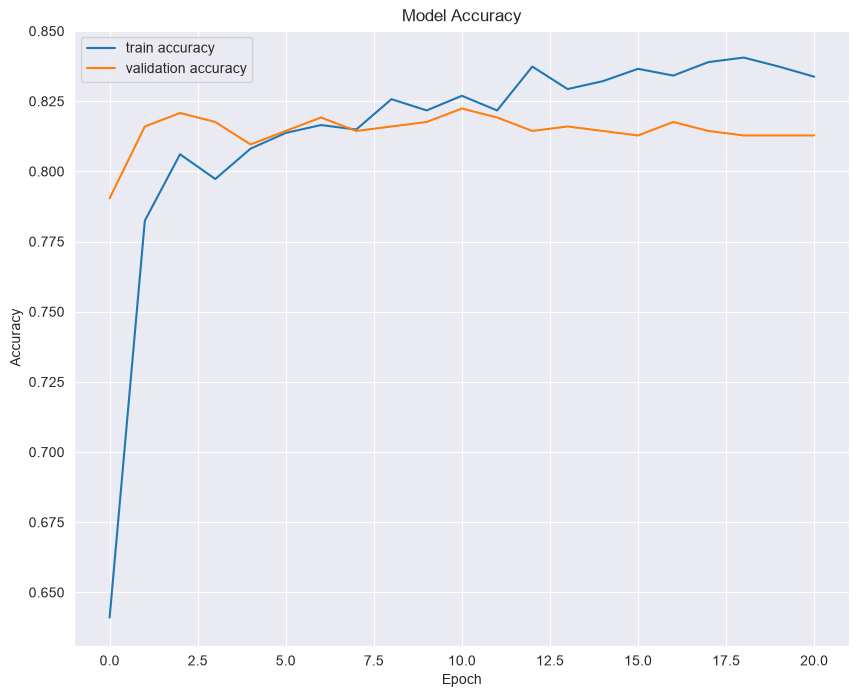

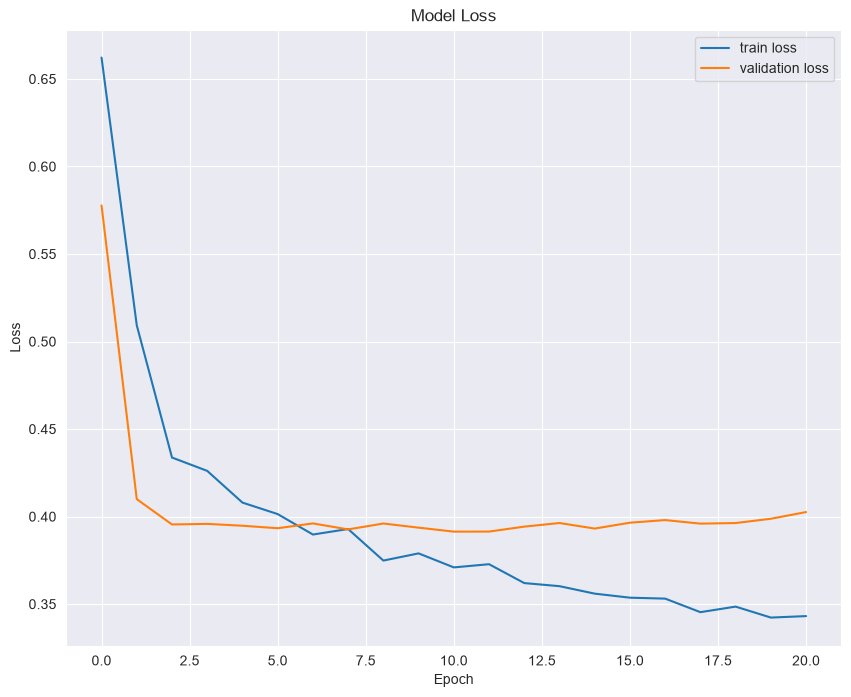

In [50]:
plt.figure(figsize=(10, 8))
plt.plot(result.history['accuracy'], label='train accuracy')
plt.plot(result.history['val_accuracy'], label='validation accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 8))
plt.plot(result.history['loss'], label='train loss')
plt.plot(result.history['val_loss'], label='validation loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()